In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score,auc
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import xgboost as xgb
import numpy as np
from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv("data/taobao_user_behavior_cut.csv")
df.head()

,Unnamed: 0,user_id,item_id,behavior_type,user_geohash,item_category,time
0,7163993,32495375,167730214,1,NaN,13712,2014-11-18 00
1,6235991,34424883,374719183,1,NaN,10392,2014-11-18 00
2,6857989,14568076,67563825,1,NaN,13515,2014-11-18 00
3,3917236,109919014,397963929,1,NaN,4116,2014-11-18 00
4,10704941,27032913,261452097,1,NaN,5699,2014-11-18 00


In [4]:
cf = df.copy()
cf[cf['behavior_type']==4].groupby('user_id')['behavior_type'].sum()

user_id
6118          4
7528          4
7591          4
79824         8
88930        12
             ..
142306250     8
142368840     4
142430177     4
142450275     8
142455899    12
Name: behavior_type, Length: 4607, dtype: int64

In [5]:
cf['time'] = pd.to_datetime(cf['time'])
cf['date'] = cf['time'].dt.date

In [6]:
cf_data = cf[cf['behavior_type'] == 4].groupby('date').size().reset_index(name='buy_count')
cf_data

,date,buy_count
0,2014-11-18,311
1,2014-11-19,319
2,2014-11-20,248
3,2014-11-21,244
4,2014-11-22,291
5,2014-11-23,238
6,2014-11-24,288
7,2014-11-25,272
8,2014-11-26,297
9,2014-11-27,332


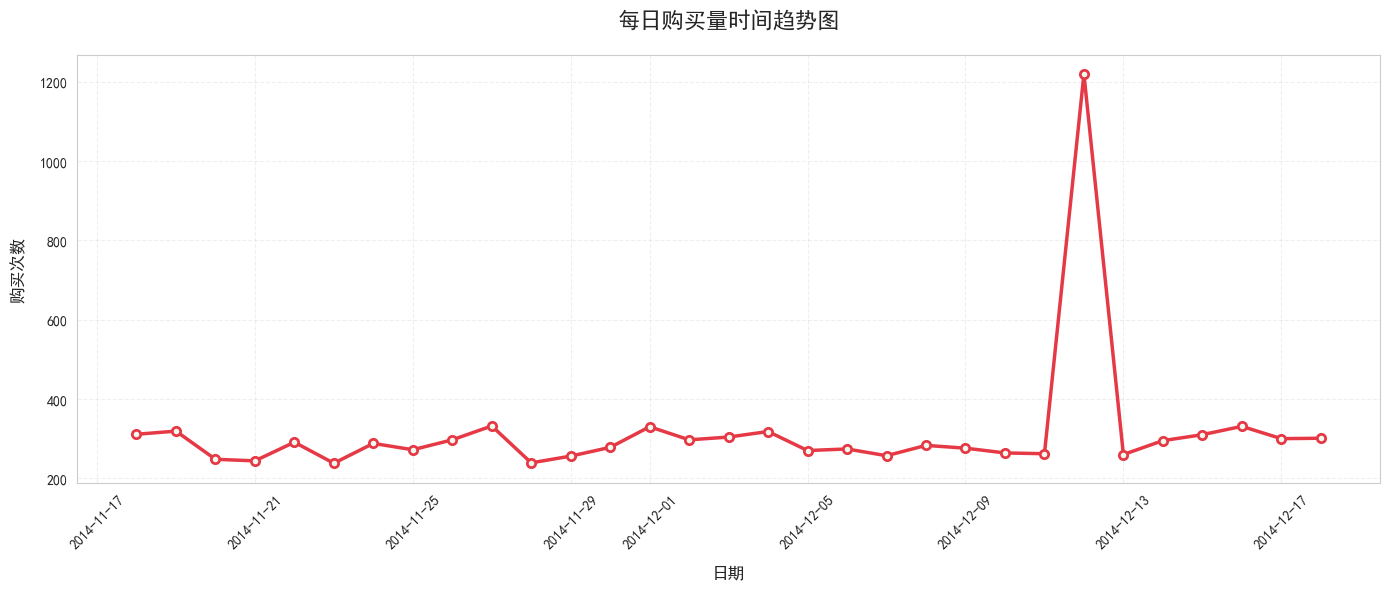

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6), dpi=100)  # 画布更大更清晰
plt.rcParams['font.sans-serif'] = ['SimHei']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False    #
sns.lineplot(
    data=cf_data,
    x="date",
    y="buy_count",
    color="#E63946",          # 高级红色
    marker="o",               # 圆点标记
    markersize=6,            # 标记大小
    markerfacecolor="#F1FAEE",# 标记填充色
    markeredgecolor="#E63946",# 标记边框色
    markeredgewidth=2,        # 标记边框粗细
    linewidth=2.5,
)

# -------------------------- 样式美化 --------------------------
plt.title('每日购买量时间趋势图', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('日期', fontsize=12, labelpad=10)
plt.ylabel('购买次数', fontsize=12, labelpad=10)

plt.xticks(rotation=45, fontsize=10)  # 日期旋转
plt.yticks(fontsize=10)
plt.grid(alpha=0.3, linestyle='--')    # 柔和网格
plt.tight_layout()                    # 适配不重叠

plt.show()

In [8]:
df['time'].value_counts().reset_index().sort_values("time")

,time,count
495,2014-11-18 00,1098
581,2014-11-18 01,613
598,2014-11-18 02,440
673,2014-11-18 03,260
680,2014-11-18 04,249
...,...,...
155,2014-12-18 19,1855
79,2014-12-18 20,2457
29,2014-12-18 21,2859
54,2014-12-18 22,2706


In [8]:
df["user_id"].unique()

array([32495375, 34424883, 14568076, ..., 61375478, 57954612, 37019520],
      shape=(9918,))

In [9]:
df = df.drop(["Unnamed: 0",'user_geohash'],axis=1)

In [10]:
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date

# 特征聚合

In [89]:
df.columns

Index(['user_id', 'item_id', 'behavior_type', 'item_category', 'time', 'date'], dtype='object')

In [11]:
df[df['behavior_type']==1] = 'view'

D:\temp\Temp\ipykernel_24396\674355047.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'view' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df[df['behavior_type']==1] = 'view'
D:\temp\Temp\ipykernel_24396\674355047.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'view' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df[df['behavior_type']==1] = 'view'
D:\temp\Temp\ipykernel_24396\674355047.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'view' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df[df['behavior_type']==1] = 'view'
D:\temp\Temp\ipykernel_24396\674355047.py:1: FutureWarning: Setting an item of incomp

In [12]:
df['behavior_type'].value_counts()

behavior_type
view    942366
3        28098
2        19772
4         9764
Name: count, dtype: int64

In [92]:
type(df['behavior_type'][0])

str

In [13]:
def build_user_samples(df, feature_start, feature_end, label_start, label_end):
    df = df.copy()

    # 时间列确保为 datetime
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df["date"] = df["time"].dt.date

    # behavior_type 映射
    behavior_map = {1: "view", 2: "cart", 3: "fav", 4: "buy"}
    df["behavior_type"] = df["behavior_type"].map(behavior_map)

    # 去掉关键列缺失
    df = df.dropna(subset=["time", "behavior_type", "user_id"])

    # 时间窗口转 datetime
    feature_start = pd.to_datetime(feature_start)
    feature_end = pd.to_datetime(feature_end)
    label_start = pd.to_datetime(label_start)
    label_end = pd.to_datetime(label_end)

    # 特征窗口
    feat_df = df[(df["time"] >= feature_start) & (df["time"] < feature_end)].copy()

    # 时间衰减评分
    behavior_weight = {4: 5}  # "buy" 的行为赋予更高权重
    feat_df["time_diff"] = (feature_end - feat_df["time"]).dt.total_seconds() / 3600
    feat_df["decay"] = np.exp(-feat_df["time_diff"] / 24)

    # 确保 behavior_type 在衰减计算时正确
    feat_df["weighted_score"] = feat_df["behavior_type"].apply(lambda x: behavior_weight.get(x, 1)) * feat_df["decay"]

    decay_score = feat_df.groupby("user_id")["weighted_score"].sum().reset_index(name="decay_score")

    # 标签窗口
    label_df = df[(df["time"] >= label_start) & (df["time"] < label_end)].copy()

    # 如果特征窗口为空，直接返回空表
    if feat_df.empty:
        return pd.DataFrame()

    # 所有候选用户：特征窗口内出现过的用户
    users = pd.DataFrame({"user_id": feat_df["user_id"].drop_duplicates()})

    # 基础行为次数
    behavior_cnt = (
        feat_df.groupby(["user_id", "behavior_type"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    # 兼容某些行为缺失
    for col in ["view", "cart", "fav", "buy"]:
        if col not in behavior_cnt.columns:
            behavior_cnt[col] = 0

    behavior_cnt = behavior_cnt.rename(columns={
        "view": "view_cnt_20d",
        "cart": "cart_cnt_20d",
        "fav": "fav_cnt_20d",
        "buy": "buy_cnt_20d"
    })

    # 活跃天数
    active_days = (
        feat_df.groupby("user_id")["date"]
        .nunique()
        .reset_index(name="active_days_20d")
    )

    # 商品/类别去重数
    nunique_stats = (
        feat_df.groupby("user_id")
        .agg(
            item_nunique_20d=("item_id", "nunique"),
            cate_nunique_20d=("item_category", "nunique")
        )
        .reset_index()
    )

    # 最近 3 天行为次数
    recent_3d_start = feature_end - pd.Timedelta(days=3)
    recent_3d = feat_df[feat_df["time"] >= recent_3d_start]

    recent_3d_cnt = (
        recent_3d.groupby("user_id")
        .size()
        .reset_index(name="recent_3d_action_cnt")
    )

    # 最近一次行为距离窗口结束多久（小时）
    last_action = (
        feat_df.groupby("user_id")["time"]
        .max()
        .reset_index(name="last_action_time")
    )

    last_action["last_action_time"] = pd.to_datetime(
        last_action["last_action_time"], errors="coerce"
    )

    last_action["last_active_gap_hours"] = (
            (feature_end - last_action["last_action_time"]).dt.total_seconds() / 3600
    )

    last_action = last_action[["user_id", "last_active_gap_hours"]]

    def get_behavior_counts(sub_df, suffix):
        tmp = (
            sub_df.groupby(["user_id", "behavior_type"])
            .size()
            .unstack(fill_value=0)
            .reset_index()
        )
        for col in ["view", "cart", "fav", "buy"]:
            if col not in tmp.columns:
                tmp[col] = 0
        return tmp.rename(columns={
            "view": f"view_cnt_{suffix}",
            "cart": f"cart_cnt_{suffix}",
            "fav": f"fav_cnt_{suffix}",
            "buy": f"buy_cnt_{suffix}",
        })

    recent_1d = feat_df[feat_df["time"] >= feature_end - pd.Timedelta(days=1)]
    recent_3d = feat_df[feat_df["time"] >= feature_end - pd.Timedelta(days=3)]
    recent_7d = feat_df[feat_df["time"] >= feature_end - pd.Timedelta(days=7)]

    cnt_1d = get_behavior_counts(recent_1d, "1d")
    cnt_3d = get_behavior_counts(recent_3d, "3d")
    cnt_7d = get_behavior_counts(recent_7d, "7d")

    def get_last_gap(feat_df, behavior, feature_end, col_name):
        tmp = (
            feat_df[feat_df["behavior_type"] == behavior]
            .groupby("user_id")["time"]
            .max()
            .reset_index(name="last_time")
        )
        tmp[col_name] = (feature_end - tmp["last_time"]).dt.total_seconds() / 3600
        return tmp[["user_id", col_name]]

    last_view = get_last_gap(feat_df, "view", feature_end, "last_view_gap_hours")
    last_cart = get_last_gap(feat_df, "cart", feature_end, "last_cart_gap_hours")
    last_fav = get_last_gap(feat_df, "fav", feature_end, "last_fav_gap_hours")
    last_buy = get_last_gap(feat_df, "buy", feature_end, "last_buy_gap_hours")

    # 合并特征
    feature_table = (
        users.merge(behavior_cnt, on="user_id", how="left")
        .merge(active_days, on="user_id", how="left")
        .merge(nunique_stats, on="user_id", how="left")
        .merge(recent_3d_cnt, on="user_id", how="left")
        .merge(last_action, on="user_id", how="left")
        .merge(cnt_1d, on="user_id", how="left")
        .merge(cnt_3d, on="user_id", how="left")
        .merge(cnt_7d, on="user_id", how="left")
        .merge(last_view, on="user_id", how="left")
        .merge(last_cart, on="user_id", how="left")
        .merge(last_fav, on="user_id", how="left")
        .merge(last_buy, on="user_id", how="left")
        .merge(decay_score, on="user_id", how="left")
    )

    feature_table = feature_table.fillna(0)

    # 转化率特征
    feature_table["cart_view_ratio"] = (
            feature_table["cart_cnt_20d"] / (feature_table["view_cnt_20d"] + 1)
    )
    feature_table["buy_view_ratio"] = (
            feature_table["buy_cnt_20d"] / (feature_table["view_cnt_20d"] + 1)
    )

    # 标签：未来窗口内是否购买
    label_users = (
        label_df[label_df["behavior_type"] == "buy"]["user_id"]
        .drop_duplicates()
        .to_frame()
    )
    label_users["label"] = 1

    sample = feature_table.merge(label_users, on="user_id", how="left")
    sample["label"] = sample["label"].fillna(0).astype(int)

    return sample

In [94]:
# df['time'].sort_values()

In [14]:
train_sample = build_user_samples(
    df,
    feature_start="2014-11-18",
    feature_end="2014-12-07",
    label_start="2014-12-08",
    label_end="2014-12-11"
)
train_sample1 = build_user_samples(
    df,
    feature_start="2014-11-19",
    feature_end="2014-12-08",
    label_start="2014-12-09",
    label_end="2014-12-12"
)
train_sample2 = build_user_samples(
    df,
    feature_start="2014-11-20",
    feature_end="2014-12-09",
    label_start="2014-12-10",
    label_end="2014-12-13"
)
train_sample3 = build_user_samples(
    df,
    feature_start="2014-11-21",
    feature_end="2014-12-10",
    label_start="2014-12-11",
    label_end="2014-12-14"
)
valid_sample = build_user_samples(
    df,
    feature_start="2014-11-22",
    feature_end="2014-12-11",
    label_start="2014-12-12",
    label_end="2014-12-15"
)
valid_sample1 = build_user_samples(
    df,
    feature_start="2014-11-23",
    feature_end="2014-12-12",
    label_start="2014-12-13",
    label_end="2014-12-16"
)
valid_sample2 = build_user_samples(
    df,
    feature_start="2014-11-24",
    feature_end="2014-12-13",
    label_start="2014-12-14",
    label_end="2014-12-17"
)

D:\temp\Temp\ipykernel_24396\905273898.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
D:\temp\Temp\ipykernel_24396\905273898.py:165: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feature_table = feature_table.fillna(0)
D:\temp\Temp\ipykernel_24396\905273898.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
D:\temp\Temp\ipykernel_24396\905273898.py:165: FutureWarning: Downcasti

In [15]:
train_sample['buy_cnt_20d'].sum()

np.int64(5406)

In [16]:
data = pd.concat([ valid_sample,train_sample1,train_sample2,train_sample3,valid_sample2])
data.drop_duplicates(inplace=True)
y = data["label"]
data.drop(['user_id', 'label'], axis=1, inplace=True)

In [18]:
data = pd.concat([train_sample, valid_sample,train_sample1,train_sample2,train_sample3,valid_sample1,valid_sample2])
data.drop_duplicates(inplace=True)
feature_cols = [c for c in train_sample.columns if c not in ["user_id", "label"]]
y = data["label"]
data.drop(['user_id', 'label'], axis=1, inplace=True)


In [32]:
data

,buy_cnt_20d,cart_cnt_20d,fav_cnt_20d,view_cnt_20d,active_days_20d,item_nunique_20d,cate_nunique_20d,recent_3d_action_cnt,last_active_gap_hours,buy_cnt_1d,...,cart_cnt_7d,fav_cnt_7d,view_cnt_7d,last_view_gap_hours,last_cart_gap_hours,last_fav_gap_hours,last_buy_gap_hours,decay_score,cart_view_ratio,buy_view_ratio
0,0,0,0,106,11,96,28,1.000000,29.000000,0.0,...,0.000000,0.000000,3.000000,29.000000,0.000000,0.000000,0.000000,3.034296e-01,0.000000,0.000000
1,6,2,18,444,18,408,116,113.000000,1.000000,1.0,...,0.000000,12.000000,244.000000,1.000000,361.000000,1.000000,21.000000,6.210588e+01,0.004494,0.013483
2,0,0,2,54,14,51,22,13.000000,5.000000,0.0,...,0.000000,0.000000,17.000000,5.000000,0.000000,217.000000,0.000000,4.631652e+00,0.000000,0.000000
3,0,0,1,13,1,12,7,0.000000,455.000000,0.0,...,0.000000,0.000000,0.000000,455.000000,0.000000,456.000000,0.000000,7.867753e-08,0.000000,0.000000
4,0,0,1,91,16,80,40,18.000000,2.000000,0.0,...,0.000000,0.000000,24.000000,2.000000,0.000000,389.000000,0.000000,1.030276e+01,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121497,2,1,6,106,18,107,71,24.619902,3.095024,0.0,...,1.190049,2.714927,31.475122,3.095024,39.520392,5.429853,202.954731,8.274174e+00,0.013641,0.026237
121498,1,9,0,57,11,57,34,9.853648,13.560945,0.0,...,0.146352,0.000000,12.707297,13.560945,181.487564,0.000000,319.487564,3.368021e+00,0.158016,0.017041
121499,0,0,0,50,14,45,29,12.452208,30.766909,0.0,...,0.000000,0.000000,20.547792,30.766909,0.000000,0.000000,0.000000,2.326842e+00,0.000000,0.000000
121500,0,0,1,50,11,42,21,19.000000,3.376153,0.0,...,0.000000,1.311924,24.559618,3.376153,0.000000,25.311924,0.000000,1.048586e+01,0.000000,0.000000


In [27]:
logic_model = DecisionTreeClassifier(random_state=42)
X_train,X_test,y_train,y_test = train_test_split(data,y,test_size=0.2,random_state=42, stratify=y)

logic_model.fit(X_train, y_train)
y_pred = logic_model.predict_proba(X_test)[:, 1]
print('AUC:', roc_auc_score(y_test, y_pred))


AUC: 0.8894518055212649


In [19]:

X_train,X_test,y_train,y_test = train_test_split(data,y,test_size=0.2,random_state=42)
# smote = SMOTE(sampling_strategy='auto', random_state=42)
# data, y = smote.fit_resample(X_train, y_train)
model = RandomForestClassifier(n_estimators=400,max_depth=8,min_samples_split=20,min_samples_leaf=10, random_state=42, n_jobs=-1, )
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_test)[:, 1]
print('AUC:', roc_auc_score(y_test, y_pred))
print('PR-AUC',average_precision_score(y_test, y_pred))

AUC: 0.624790125067957
PR-AUC 0.22204219706506573


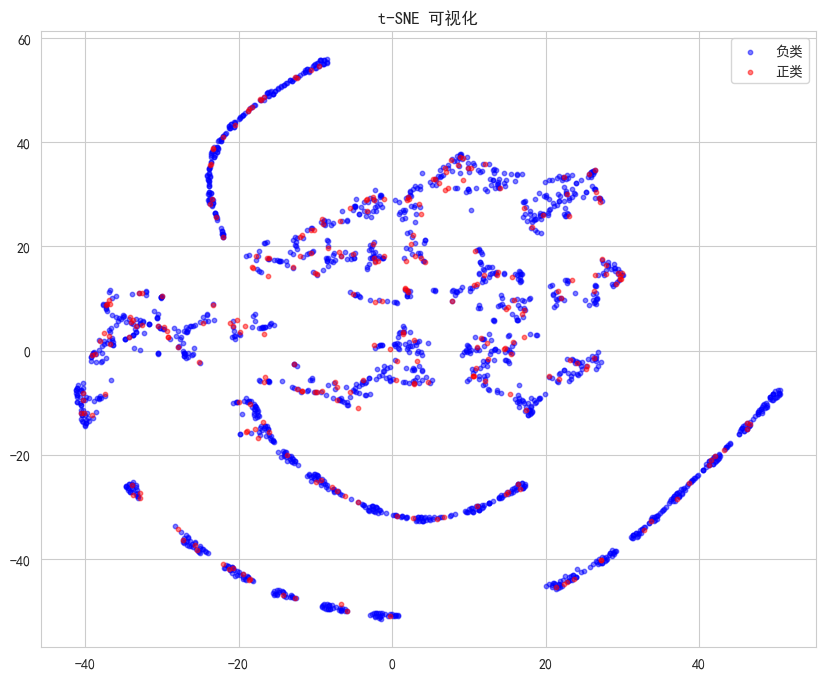

In [20]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 降维可视化（取部分样本）
sample_size = min(2000, len(X_train))
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train[:sample_size])

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[y_train[:sample_size]==0, 0],
            X_tsne[y_train[:sample_size]==0, 1],
            c='blue', label='负类', alpha=0.5, s=10)
plt.scatter(X_tsne[y_train[:sample_size]==1, 0],
            X_tsne[y_train[:sample_size]==1, 1],
            c='red', label='正类', alpha=0.5, s=10)
plt.legend()
plt.title('t-SNE 可视化')
plt.show()

In [30]:
X_train,X_test,y_train,y_test = train_test_split(data,y,test_size=0.2,random_state=42, stratify=y)
model = XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_test)
print('AUC:', roc_auc_score(y_test, y_pred[:, 1]))


AUC: 0.9413290409805556


In [102]:
y.value_counts()

label
0    40375
1     5532
Name: count, dtype: int64

In [103]:
X_train,X_test,y_train,y_test = train_test_split(data,y,test_size=0.2,random_state=42, stratify=y)
dataTrain = xgb.DMatrix(X_train,label=y_train)
dataTest = xgb.DMatrix(X_test,label=y_test)

# params={'booster':'gbtree',      'objective': 'rank:pairwise',      'eval_metric':'auc',      'gamma':0.1,      'min_child_weight':1.1,      'max_depth':5,      'lambda':10,      'subsample':0.7,      'colsample_bytree':0.7,      'colsample_bylevel':0.7,      'eta': 0.01,      'tree_method':'exact',      'seed':0,      'nthread':12      }
params={'eval_metric':'auc'}
watchlist = [(dataTrain,'train'), (dataTest,'test')]
model = xgb.train(params,dataTrain,num_boost_round=100,evals=watchlist)

[0]	train-auc:0.65408	test-auc:0.60661
[1]	train-auc:0.65936	test-auc:0.61556
[2]	train-auc:0.66357	test-auc:0.61795
[3]	train-auc:0.66895	test-auc:0.62020
[4]	train-auc:0.67282	test-auc:0.62291
[5]	train-auc:0.67501	test-auc:0.62466
[6]	train-auc:0.67732	test-auc:0.62583
[7]	train-auc:0.67981	test-auc:0.62627
[8]	train-auc:0.68338	test-auc:0.62860
[9]	train-auc:0.68451	test-auc:0.62648
[10]	train-auc:0.68664	test-auc:0.62688
[11]	train-auc:0.69046	test-auc:0.62946
[12]	train-auc:0.69330	test-auc:0.62924
[13]	train-auc:0.69525	test-auc:0.63059
[14]	train-auc:0.69635	test-auc:0.63093
[15]	train-auc:0.69926	test-auc:0.63138
[16]	train-auc:0.70023	test-auc:0.63183
[17]	train-auc:0.70142	test-auc:0.63184
[18]	train-auc:0.70283	test-auc:0.63194
[19]	train-auc:0.70377	test-auc:0.63142
[20]	train-auc:0.70669	test-auc:0.63126
[21]	train-auc:0.70841	test-auc:0.63170
[22]	train-auc:0.71096	test-auc:0.63114
[23]	train-auc:0.71466	test-auc:0.63210
[24]	train-auc:0.71542	test-auc:0.63214
[25]	train

KeyboardInterrupt: 

In [154]:
data.columns

Index(['buy_cnt_20d', 'cart_cnt_20d', 'fav_cnt_20d', 'view_cnt_20d',
       'active_days_20d', 'item_nunique_20d', 'cate_nunique_20d',
       'recent_3d_action_cnt', 'last_active_gap_hours', 'buy_cnt_1d',
       'cart_cnt_1d', 'fav_cnt_1d', 'view_cnt_1d', 'buy_cnt_3d', 'cart_cnt_3d',
       'fav_cnt_3d', 'view_cnt_3d', 'buy_cnt_7d', 'cart_cnt_7d', 'fav_cnt_7d',
       'view_cnt_7d', 'last_view_gap_hours', 'last_cart_gap_hours',
       'last_fav_gap_hours', 'last_buy_gap_hours', 'decay_score',
       'cart_view_ratio', 'buy_view_ratio'],
      dtype='object')

In [156]:
print(model.feature_importances_)
importance_df = pd.DataFrame({
    "feature": model.feature_name_,
    "importance": model.feature_importances_
})
threshold = 0.05  # 设定一个重要性阈值
important_features = importance_df[importance_df["importance"] > threshold]["feature"].tolist()
print(important_features)

[ 585  704  712    0  766  769  799  240 1213   60   48   66    0   86
  152  145    0  321  434  482    0    0 1154 1333 1281 1237    0    0]
['buy_cnt_20d', 'cart_cnt_20d', 'fav_cnt_20d', 'active_days_20d', 'item_nunique_20d', 'cate_nunique_20d', 'recent_3d_action_cnt', 'last_active_gap_hours', 'buy_cnt_1d', 'cart_cnt_1d', 'fav_cnt_1d', 'buy_cnt_3d', 'cart_cnt_3d', 'fav_cnt_3d', 'buy_cnt_7d', 'cart_cnt_7d', 'fav_cnt_7d', 'last_cart_gap_hours', 'last_fav_gap_hours', 'last_buy_gap_hours', 'decay_score']


In [29]:
model = LGBMClassifier( scale_pos_weight = 8076 / 1106,  # 7.3  必须写这个！
                        learning_rate=0.03,
                        n_estimators=500,
                        max_depth=128,
                        random_state=42)
X_train,X_test,y_train,y_test = train_test_split(data,y,test_size=0.2,random_state=42, stratify=y)
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_test)
print(np.bincount(y_test))
print('AUC:', roc_auc_score(y_test, y_pred[:, 1]))
print("PR-AUC",average_precision_score(y_test, y_pred[:,1]))
print(model.feature_importances_)

[LightGBM] [Info] Number of positive: 48601, number of negative: 48600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004323 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6205
[LightGBM] [Info] Number of data points in the train set: 97201, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500005 -> initscore=0.000021
[LightGBM] [Info] Start training from score 0.000021
[12151 12150]
AUC: 0.954916403432392
PR-AUC 0.9682825178024705
[ 154  177  229  575  456  570  822  734  978   54   79  218 1310  122
  184  231  901  296  404  604 1824 1368  303  620  485  475  372  455]


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import numpy as np
from xgboost import XGBClassifier

X_train = train_sample[feature_cols]
y_train = train_sample["label"]

X_valid = valid_sample[feature_cols]
y_valid = valid_sample["label"]

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.5,
    verbose=100,
)
# model = XGBClassifier(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=5,
#     random_state=42,
#     scale_pos_weight=spw,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=0.1,
#     reg_lambda=0.5,
#     objective='binary:logistic',
#     eval_metric='auc',
#     use_label_encoder=False,
#     verbose=100,
# )
model.fit(X_train, y_train)

valid_prob = model.predict_proba(X_valid)[:, 1]
print(np.sort(valid_prob)[::-1][:50])
print("ROC-AUC:", roc_auc_score(y_valid, valid_prob))
print("PR-AUC:", average_precision_score(y_valid, valid_prob))

for th in [0.5, 0.4, 0.3, 0.2, 0.1]:
    pred = (valid_prob >= th).astype(int)
    print(f"\nthreshold={th}")
    print(classification_report(y_valid, pred))

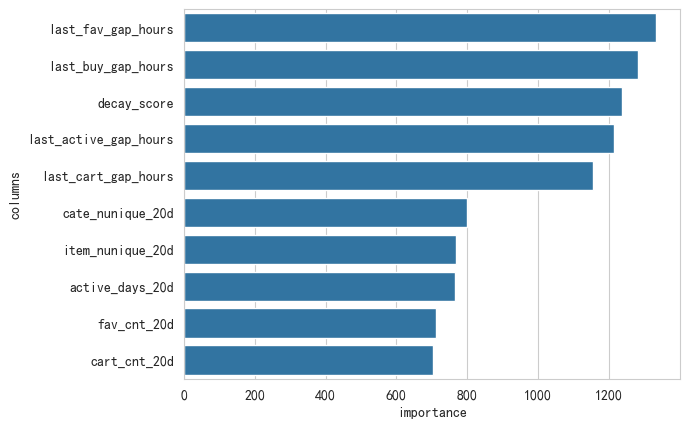

In [158]:
imp = pd.DataFrame(
    {'columns':X_train.columns,
    'importance':model.feature_importances_}
).sort_values('importance',ascending=False)
sns.barplot(data=imp.head(10),x='importance',y='columns')
plt.show()

In [ ]:
print(imp)